# HANDS ON COVID-19 PROJECT — COMBINED & DEPLOYABLE MODEL

This notebook combines the required data preparation and Prophet forecasting code from Part 1 and Part 2 with minimal changes. The trained model is saved as `model.pkl` for deployment.

In [1]:
# Basic Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import pickle

warnings.filterwarnings("ignore")

In [2]:
# Load the same COVID-19 CSV used in Part 1 and Part 2
df = pd.read_csv("Covid_19_Clean_Complete 1.csv")
df

,Province/State,Country/Region,Lat,Long,Date,Confirmed,Deaths,Recovered,Active,WHO Region
0,NaN,Afghanistan,33.939110,67.709953,2020-01-22,0,0,0,0,Eastern Mediterranean
1,NaN,Albania,41.153300,20.168300,2020-01-22,0,0,0,0,Europe
2,NaN,Algeria,28.033900,1.659600,2020-01-22,0,0,0,0,Africa
3,NaN,Andorra,42.506300,1.521800,2020-01-22,0,0,0,0,Europe
4,NaN,Angola,-11.202700,17.873900,2020-01-22,0,0,0,0,Africa
...,...,...,...,...,...,...,...,...,...,...
49063,NaN,Sao Tome and Principe,0.186400,6.613100,2020-07-27,865,14,734,117,Africa
49064,NaN,Yemen,15.552727,48.516388,2020-07-27,1691,483,833,375,Eastern Mediterranean
49065,NaN,Comoros,-11.645500,43.333300,2020-07-27,354,7,328,19,Africa
49066,NaN,Tajikistan,38.861000,71.276100,2020-07-27,7235,60,6028,1147,Europe


In [3]:
# Convert date strings into datetime objects for time series analysis.
df['Date'] = pd.to_datetime(df['Date'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 49068 entries, 0 to 49067
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Province/State  14664 non-null  object        
 1   Country/Region  49068 non-null  object        
 2   Lat             49068 non-null  float64       
 3   Long            49068 non-null  float64       
 4   Date            49068 non-null  datetime64[ns]
 5   Confirmed       49068 non-null  int64         
 6   Deaths          49068 non-null  int64         
 7   Recovered       49068 non-null  int64         
 8   Active          49068 non-null  int64         
 9   WHO Region      49068 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(4), object(3)
memory usage: 3.7+ MB


In [4]:
# Calculate total confirmed COVID-19 cases for each date.
confirmed_cases = df.groupby(by='Date')['Confirmed'].sum().reset_index()
confirmed_cases

,Date,Confirmed
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


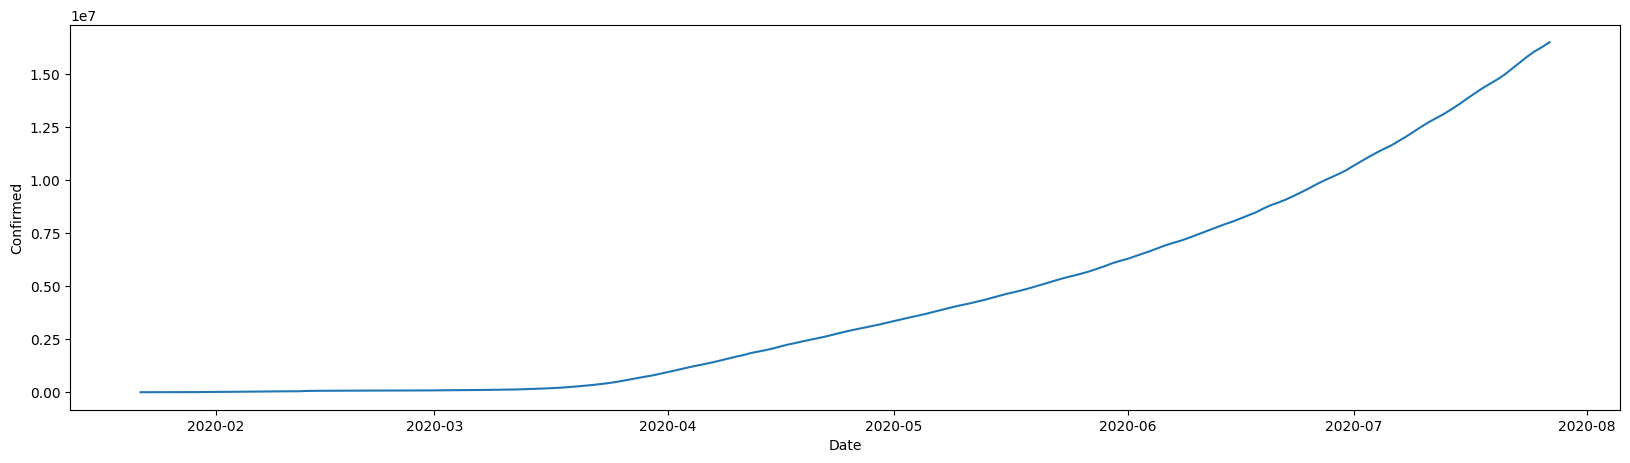

In [5]:
# Visualize confirmed COVID-19 cases over time.
plt.figure(figsize=(20, 5))
sns.lineplot(data=confirmed_cases, x='Date', y='Confirmed')
plt.show()

In [6]:
# Prophet requires the date column as 'ds' and target column as 'y'.
confirmed_cases.columns = ['ds', 'y']
confirmed_cases

,ds,y
0,2020-01-22,555
1,2020-01-23,654
2,2020-01-24,941
3,2020-01-25,1434
4,2020-01-26,2118
...,...,...
183,2020-07-23,15510481
184,2020-07-24,15791645
185,2020-07-25,16047190
186,2020-07-26,16251796


In [9]:
from prophet import Prophet

In [10]:
# Train the Prophet forecasting model.
fp_prophet_model = Prophet()
fp_prophet_model.fit(confirmed_cases)

23:27:27 - cmdstanpy - INFO - Chain [1] start processing
23:27:31 - cmdstanpy - INFO - Chain [1] done processing


In [11]:
# Forecast the next 15 days.
forecated_future_values = fp_prophet_model.make_future_dataframe(periods=15)
forecated_future_values

,ds
0,2020-01-22
1,2020-01-23
2,2020-01-24
3,2020-01-25
4,2020-01-26
...,...
198,2020-08-07
199,2020-08-08
200,2020-08-09
201,2020-08-10


In [12]:
# Generate future predictions with lower and upper confidence intervals.
predicted_future_values = fp_prophet_model.predict(forecated_future_values)
predicted_future_values[['ds', 'yhat', 'yhat_upper', 'yhat_lower']]

,ds,yhat,yhat_upper,yhat_lower
0,2020-01-22,-2.049744e+04,8.654563e+04,-1.229497e+05
1,2020-01-23,-7.896286e+03,9.669181e+04,-1.063774e+05
2,2020-01-24,5.975182e+03,1.089102e+05,-1.027415e+05
3,2020-01-25,1.237060e+04,1.126981e+05,-9.323831e+04
4,2020-01-26,8.615242e+03,1.163583e+05,-1.082637e+05
...,...,...,...,...
198,2020-08-07,1.838711e+07,1.852935e+07,1.824474e+07
199,2020-08-08,1.859481e+07,1.875174e+07,1.845199e+07
200,2020-08-09,1.879236e+07,1.896759e+07,1.863357e+07
201,2020-08-10,1.898699e+07,1.915573e+07,1.880992e+07


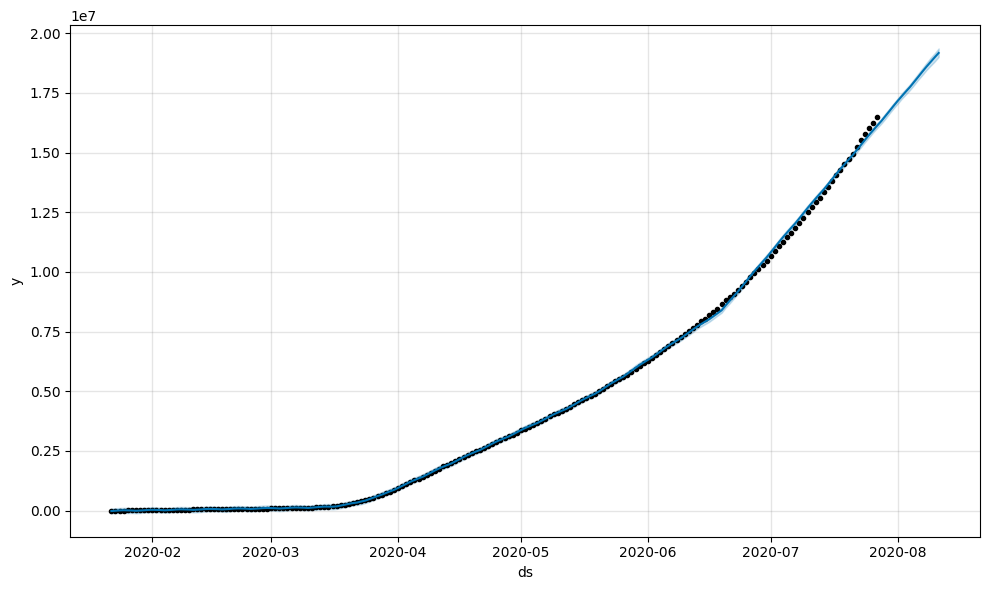

In [13]:
# Plot the Prophet forecast.
fp_prophet_model.plot(predicted_future_values)
plt.show()

## Save the trained model for deployment

In [14]:
# Save the complete trained Prophet model as model.pkl.
with open('model.pkl', 'wb') as model_file:
    pickle.dump(fp_prophet_model, model_file)

print('model.pkl saved successfully.')

model.pkl saved successfully.


## Deployment / Prediction Test

In [15]:
# Load the saved model exactly as it can be loaded in a deployment application.
with open('model.pkl', 'rb') as model_file:
    loaded_model = pickle.load(model_file)

# Generate predictions from the saved model.
deployment_future_values = loaded_model.make_future_dataframe(periods=15)
deployment_predictions = loaded_model.predict(deployment_future_values)
deployment_predictions[['ds', 'yhat', 'yhat_upper', 'yhat_lower']].tail(15)

,ds,yhat,yhat_upper,yhat_lower
188,2020-07-28,1.632012e+07,1.642058e+07,1.621191e+07
189,2020-07-29,1.652995e+07,1.663238e+07,1.642580e+07
190,2020-07-30,1.674386e+07,1.685508e+07,1.663554e+07
191,2020-07-31,1.695903e+07,1.706914e+07,1.685194e+07
192,2020-08-01,1.716674e+07,1.727858e+07,1.705901e+07
193,2020-08-02,1.736429e+07,1.748035e+07,1.724095e+07
194,2020-08-03,1.755891e+07,1.766850e+07,1.744514e+07
195,2020-08-04,1.774819e+07,1.787593e+07,1.762904e+07
196,2020-08-05,1.795803e+07,1.808581e+07,1.783611e+07
197,2020-08-06,1.817193e+07,1.831178e+07,1.803766e+07
